<a href="https://colab.research.google.com/github/nika19du/AI-for-Developers-summer-2026-/blob/main/LangChain(Agent).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q langchain langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.0/570.0 kB 15.6 MB/s eta 0:00:00


In [3]:
from google.colab import userdata
from langchain.agents import create_agent
from langchain.messages import AIMessage, HumanMessage
from langchain.tools import tool
from langchain_openai import ChatOpenAI
from pathlib import Path
from pydantic import SecretStr
from typing import List

def print_conversation(conversation: List[AIMessage]):
    for message in conversation:
        message.pretty_print()

In [4]:
@tool
def lookup_tour_stop(artist: str) -> str:
    """
    Look up the next city and venue for an artist from a small curated tour calendar.

    Args:
        artist: The artist or band name to search for
    """

    stops = {
        "breaking benjaming": "Sofia - Arena 8888",
        "placido domingo": "Varna - Palace of Culture and Sports",
        "vassil petrov & jp3": "Shumen - City Stage",
    }

    return stops.get(artist.strip().lower(), "Could not find any tour stops.")

@tool
def estimate_drive_time(origin: str, destination: str) -> str:
    """
    Estimate drive time between cities in Bulgaria.

    Args:
      origin: The departure city.
      destination: The arrival city.
    """
    routes = {
        ("plovdiv","sofia"): "About 1 hour and 45 minutes",
        ("shumen", "varna"): "About 1 hour",
        ("plovdiv", "shumen"): "About 2 hours and 30 minutes."
    }

    key = (origin.strip().lower(), destination.strip().lower())
    return routes.get(key, "Could not estimate the drive time.")

In [5]:
api_key = SecretStr(userdata.get('OPENAI_API_KEY'))
model = ChatOpenAI(model = "gpt-5-nano", api_key = api_key)

agent = create_agent(
    model = model,
    tools = [lookup_tour_stop, estimate_drive_time],
    system_prompt = "You are a practical live-music concierge. Use tools when they help you give a precise answer."
)

In [6]:
plan_concert_trip = agent.invoke(
    input = {
        "messages": [HumanMessage("I'm in Plovdiv on Friday and want to hear live jazz without wasting the whole evening on travel. Check the current mini tour for \"Vassil Petrov & JP3\", figure out the relevant venue, and estimate the drive time.")]
    }
)

In [8]:
print_conversation(plan_concert_trip['messages'])

================================ Human Message =================================

I'm in Plovdiv on Friday and want to hear live jazz without wasting the whole evening on travel. Check the current mini tour for "Vassil Petrov & JP3", figure out the relevant venue, and estimate the drive time.
================================== Ai Message ==================================
Tool Calls:
  lookup_tour_stop (call_xHDzbcD056q9mtwuricGZINS)
 Call ID: call_xHDzbcD056q9mtwuricGZINS
  Args:
    artist: Vassil Petrov & JP3
================================= Tool Message =================================
Name: lookup_tour_stop

Shumen - City Stage
================================== Ai Message ==================================
Tool Calls:
  estimate_drive_time (call_hAO63EIRO7t73obbWFM0ZhTr)
 Call ID: call_hAO63EIRO7t73obbWFM0ZhTr
  Args:
    origin: Plovdiv
    destination: Shumen
================================= Tool Message =================================
Name: estimate_drive_time

About 2 ho

In [9]:
from IPython.display import Image
from langchain_core.runnables import Runnable
from pathlib import Path

def display_graph(runnable: Runnable, output_png: Path) -> None:
    graph = runnable.get_graph()

    with output_png.open(mode="wb") as file:
        file.write(graph.draw_mermaid_png())

    display(Image(output_png, format="png"))

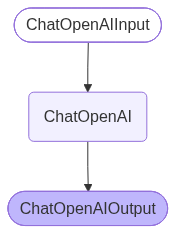

In [11]:
display_graph(model, Path('/content/model.png'))

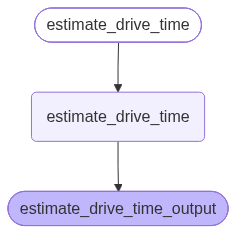

In [12]:
display_graph(estimate_drive_time, Path("/content/estimate_drive_time.png"))

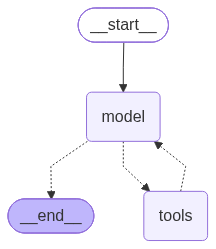

In [14]:
display_graph(agent, Path("/content/agent.png"))
# модела се обръща към туловете многократно до момента когато нямаме повече tool_calls, достига до крайното състояние просто да приключи с изпълнението на текущата задача.

In [17]:
# Model - stateless
# Agent - Stateful - не означава че агента помни, а поддържа state, който state се инициализира в start node -> с течение на времето  докато агента итерира, работейки върху задачата този state се надгражда,разширява се с нови съобщения, запълва се с нови съобщения. но в момента в който достигнем end_node губи всякаква следа.
# Stateful e от start-end
check_memory = agent.invoke(
    input = {
        "messages": [HumanMessage("What do you remember about me?")]
    }
)

In [19]:
print_conversation(check_memory['messages'])

================================ Human Message =================================

What do you remember about me?
================================== Ai Message ==================================

I don’t have memory of you from past chats. I don’t retain personal data between sessions unless you share it during this conversation. I can remember details you tell me for this chat to tailor recommendations.

If you’d like, tell me some details now—like your city, music genres you love, favorite venues, or upcoming trips—and I’ll tailor suggestions. Or tell me an artist you’re into and I can look up their next tour stop.


In [20]:
[
            *plan_concert_trip['messages'],
            HumanMessage("What do you remember about me?")
        ]

[HumanMessage(content='I\'m in Plovdiv on Friday and want to hear live jazz without wasting the whole evening on travel. Check the current mini tour for "Vassil Petrov & JP3", figure out the relevant venue, and estimate the drive time.', additional_kwargs={}, response_metadata={}, id='24df774d-d42b-4cd0-848b-d8daf61b004b'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 416, 'prompt_tokens': 263, 'total_tokens': 679, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 384, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EEsHjDrbxczTRCr2OnLYnlNPA6Wvm', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a01e40-f93a-77b0-8ca8-c090e5ad3c63-0', t

In [21]:
# Model - stateless
# Agent - Stateful - не означава че агента помни, а поддържа state, който state се инициализира в start node -> с течение на времето  докато агента итерира, работейки върху задачата този state се надгражда,разширява се с нови съобщения, запълва се с нови съобщения. но в момента в който достигнем end_node губи всякаква следа.
# Stateful e от start-end
check_memory_convs = agent.invoke(
    input = {
        "messages": [
            *plan_concert_trip['messages'], # спомен от предишната интеракция долепени с новото съобщение
            HumanMessage("What do you remember about me?")
        ]
    }
)

In [23]:
print_conversation(check_memory_convs['messages'])

================================ Human Message =================================

I'm in Plovdiv on Friday and want to hear live jazz without wasting the whole evening on travel. Check the current mini tour for "Vassil Petrov & JP3", figure out the relevant venue, and estimate the drive time.
================================== Ai Message ==================================
Tool Calls:
  lookup_tour_stop (call_xHDzbcD056q9mtwuricGZINS)
 Call ID: call_xHDzbcD056q9mtwuricGZINS
  Args:
    artist: Vassil Petrov & JP3
================================= Tool Message =================================
Name: lookup_tour_stop

Shumen - City Stage
================================== Ai Message ==================================
Tool Calls:
  estimate_drive_time (call_hAO63EIRO7t73obbWFM0ZhTr)
 Call ID: call_hAO63EIRO7t73obbWFM0ZhTr
  Args:
    origin: Plovdiv
    destination: Shumen
================================= Tool Message =================================
Name: estimate_drive_time

About 2 ho